# LM Evaluation Harness를 사용한 모델 평가
EleutherAI의 `lm-evaluation-harness`를 사용하여 Base 모델과 Fine-tuned 모델의 성능을 비교합니다.


## LM Evaluation Harness란?
LM Evaluation Harness는 EleutherAI에서 개발한 대규모 언어 모델(LLM) 평가를 위한 통합 프레임워크입니다.


### 주요 특징
- 200개 이상의 벤치마크 태스크 지원
- 다양한 모델 유형 지원 (Hugging Face, OpenAI API, vLLM 등)
- 재현 가능한 평가 결과
- 간단한 CLI 인터페이스


## 1. 설치 및 임포트

먼저 필요한 라이브러리를 임포트합니다.


In [1]:
import lm_eval

print(f"✓ lm-eval이 설치되어 있습니다.")
print(f"lm-eval 버전: {lm_eval.__version__}")

✓ lm-eval이 설치되어 있습니다.
lm-eval 버전: 0.4.9.2


## 2. 사용 가능한 태스크 확인

lm-eval에서 지원하는 태스크 목록을 확인할 수 있습니다.


In [2]:
import subprocess

# 사용 가능한 모든 태스크 나열 (일부만 표시)
result = subprocess.run(['lm_eval', '--tasks', 'list'], 
                       capture_output=True, text=True, encoding='utf-8')


In [3]:
lines = result.stdout.split('\n')
for i, line in enumerate(lines[:10], 1):
    print(line)


|                      Group                      |                                                               Config Location                                                               |
|-------------------------------------------------|---------------------------------------------------------------------------------------------------------------------------------------------|
|AraDiCE                                          |lm_eval/tasks/aradice/aradice.yaml                                                                                                           |
|AraDiCE_ArabicMMLU_egy                           |lm_eval/tasks/aradice/ArabicMMLU/EGY/AraDiCE_ArabicMMLU.yaml                                                                                 |
|AraDiCE_ArabicMMLU_lev                           |lm_eval/tasks/aradice/ArabicMMLU/LEV/AraDiCE_ArabicMMLU.yaml                                                                                 |
|aclue                       

### 주요 태스크 카테고리 및 상세 설명

lm-eval은 200개 이상의 벤치마크를 제공하며, 다음과 같은 카테고리로 분류할 수 있습니다.


#### 1. 일반 지식 및 이해력 평가

**MMLU (Massive Multitask Language Understanding)**
- **설명**: 57개 과목(수학, 역사, 법학, 의학 등)에 걸친 객관식 문제
- **샘플 수**: 약 15,700개 문제
- **사용 목적**: 
  - 모델의 광범위한 지식 수준 평가
  - 다양한 학문 분야에서의 이해력 측정
  - 전문 지식 능력 평가
- **장점**:
  - ✅ 포괄적인 지식 평가
  - ✅ 표준화된 벤치마크로 널리 사용됨
  - ✅ 도메인별 성능 분석 가능
- **단점**:
  - ❌ 실행 시간이 오래 걸림
  - ❌ 단순 암기보다는 이해력이 필요
  - ❌ 문화적 편향 가능성
- **권장 사용**: 일반 목적 모델의 전반적 지식 수준 평가


**ARC (AI2 Reasoning Challenge)**
- **설명**: 초중등 과학 시험 문제 (Easy/Challenge 두 버전)
- **샘플 수**: Easy 2,376개, Challenge 1,172개
- **사용 목적**:
  - 과학적 추론 능력 평가
  - 복잡한 논리적 사고 측정
- **장점**:
  - ✅ 난이도별 평가 가능 (Easy vs Challenge)
  - ✅ 추론 능력에 초점
  - ✅ 비교적 빠른 실행 시간
- **단점**:
  - ❌ 과학 분야에 편중됨
  - ❌ Challenge 버전은 매우 어려움
- **권장 사용**: 추론 능력 개선 여부 확인


#### 2. 상식 추론 (Commonsense Reasoning)

**HellaSwag**
- **설명**: 일상적 상황에서 다음에 일어날 일을 예측하는 문장 완성 문제
- **샘플 수**: 약 10,000개
- **사용 목적**:
  - 상식적 추론 능력 평가
  - 일상적 상황 이해도 측정
  - 문맥 파악 능력 평가
- **장점**:
  - ✅ 빠른 실행 속도
  - ✅ 일상 언어 이해도 측정
  - ✅ 많은 모델 평가에서 표준으로 사용
- **단점**:
  - ❌ 정답이 명확하지 않은 경우도 있음
  - ❌ 인간에게는 쉽지만 모델에게는 어려움
- **권장 사용**: 빠른 성능 체크, 상식 추론 능력 평가

**PIQA (Physical Interaction QA)**
- **설명**: 물리적 상식에 관한 질문 응답
- **샘플 수**: 약 1,800개
- **사용 목적**: 물리적 세계에 대한 상식 이해도 평가
- **장점**:
  - ✅ 매우 빠른 실행
  - ✅ 실용적 상식 평가
- **단점**:
  - ❌ 데이터셋 크기가 작음
- **권장 사용**: 물리적 상식 추론 능력 확인

**WinoGrande**
- **설명**: 대명사 해소 문제 (문맥에서 대명사가 누구를 가리키는지)
- **샘플 수**: 약 44,000개
- **사용 목적**: 문맥 이해 및 추론 능력 평가
- **장점**:
  - ✅ 명확한 정답
  - ✅ 편향 최소화
- **단점**:
  - ❌ 특정 유형의 추론에만 집중
- **권장 사용**: 문맥 파악 능력 측정


#### 3. 수학적 추론 (Mathematical Reasoning)

**GSM8K (Grade School Math 8K)**
- **설명**: 초등학교 수준의 수학 문장제 문제
- **샘플 수**: 8,500개
- **사용 목적**:
  - 수학적 추론 능력 평가
  - 단계별 문제 해결 능력 측정
  - 산술 능력 평가
- **장점**:
  - ✅ 명확한 정답
  - ✅ 다단계 추론 필요
  - ✅ 실용적인 문제들
- **단점**:
  - ❌ 난이도가 높아 작은 모델에는 부적합
  - ❌ 영어 이해력도 필요
- **권장 사용**: 수학/추론 능력이 중요한 모델 평가


**MATH**
- **설명**: 고등학교 수준의 경시대회 수학 문제
- **샘플 수**: 12,500개
- **사용 목적**: 고급 수학적 추론 능력 평가
- **장점**:
  - ✅ 매우 도전적
  - ✅ 다양한 수학 분야 포함
- **단점**:
  - ❌ 매우 어려움 (대부분 모델이 낮은 점수)
  - ❌ 실행 시간이 김
- **권장 사용**: 고급 수학 능력 평가


**TriviaQA**
- **설명**: 일반 상식 퀴즈 질문
- **샘플 수**: 약 95,000개
- **사용 목적**: 지식 검색 및 질문 응답 능력 평가
- **장점**:
  - ✅ 대규모 데이터셋
  - ✅ 다양한 주제
- **단점**:
  - ❌ 정답이 여러 형태일 수 있음
- **권장 사용**: QA 시스템 성능 평가


#### 4. 코딩 능력 (Coding)

**HumanEval**
- **설명**: Python 함수 작성 문제 (함수 시그니처와 docstring 제공)
- **샘플 수**: 164개
- **사용 목적**:
  - 코드 생성 능력 평가
  - 프로그래밍 문제 해결 능력 측정
- **장점**:
  - ✅ 실제 실행 가능한 코드로 평가
  - ✅ 명확한 평가 기준 (테스트 케이스 통과 여부)
  - ✅ 업계 표준 벤치마크
- **단점**:
  - ❌ 샘플 수가 적음
  - ❌ Python에만 국한됨
  - ❌ 실행 환경 필요
- **권장 사용**: 코드 생성 모델 평가


**MBPP (Mostly Basic Programming Problems)**
- **설명**: 기초적인 Python 프로그래밍 문제
- **샘플 수**: 974개
- **사용 목적**: 기본적인 프로그래밍 능력 평가
- **장점**:
  - ✅ HumanEval보다 많은 샘플
  - ✅ 다양한 난이도
- **단점**:
  - ❌ 실행 환경 필요
- **권장 사용**: 코딩 능력의 기초 평가


#### 5. 진실성 및 신뢰성 (Truthfulness)

**TruthfulQA**
- **설명**: 모델이 거짓 정보나 흔한 오해를 반복하지 않는지 평가
- **샘플 수**: 817개
- **사용 목적**:
  - 모델의 진실성 평가
  - 흔한 오해나 거짓 정보 생성 방지 확인
  - 안전성 및 신뢰성 측정
- **장점**:
  - ✅ 실용적으로 매우 중요
  - ✅ 모델의 안전성 평가
  - ✅ 편향 및 거짓 정보 생성 방지
- **단점**:
  - ❌ 평가가 복잡함 (다중 정답 가능)
  - ❌ 문화적 맥락에 따라 달라질 수 있음
  - ❌ 샘플 수가 적음
- **권장 사용**: 배포 전 안전성 검증, 신뢰성 평가


**MMLU-Pro**
- **설명**: MMLU의 강화 버전으로 더 어려운 문제들
- **샘플 수**: 약 12,000개
- **사용 목적**: 고급 지식 및 추론 능력 평가
- **장점**:
  - ✅ 더 도전적인 평가
  - ✅ 최신 모델 성능 비교에 적합
- **단점**:
  - ❌ 매우 어려움
  - ❌ 작은 모델에는 부적합
- **권장 사용**: 고성능 모델 비교


#### 6. 언어 이해 및 생성 (Language Understanding)

**BoolQ**
- **설명**: 예/아니오로 답하는 독해 문제
- **샘플 수**: 약 16,000개
- **사용 목적**: 독해 및 이진 분류 능력 평가
- **장점**:
  - ✅ 간단명료한 평가
  - ✅ 빠른 실행
- **단점**:
  - ❌ 50% 무작위 정확도
- **권장 사용**: 기본적인 언어 이해 평가


**LAMBADA**
- **설명**: 긴 문맥에서 마지막 단어 예측
- **샘플 수**: 5,153개
- **사용 목적**: 장문 문맥 이해 능력 평가
- **장점**:
  - ✅ 긴 문맥 처리 능력 측정
  - ✅ 빠른 실행
- **단점**:
  - ❌ 단어 예측에만 집중
- **권장 사용**: 긴 문맥 이해 능력 확인


**SQuAD (Stanford Question Answering Dataset)**
- **설명**: 지문을 읽고 질문에 답하는 독해 문제
- **샘플 수**: 약 100,000개
- **사용 목적**: 독해 및 정보 추출 능력 평가
- **장점**:
  - ✅ 대규모 데이터셋
  - ✅ 실용적인 QA 능력 측정
- **단점**:
  - ❌ 실행 시간이 김
- **권장 사용**: QA 모델 성능 평가


### 태스크 선택 가이드

평가 목적에 따라 적절한 태스크를 선택하세요:


#### 목적별 추천 태스크 조합

**1. 빠른 성능 체크 (10-20분)**
> 상식 추론, 기본 과학 지식, 언어 이해를 빠르게 평가

```shell
--tasks hellaswag,arc_easy,boolq --limit 100
```


**2. 일반 모델 종합 평가 (1-2시간)**
> 업계 표준 벤치마크로 광범위한 능력 평가

```shell
--tasks mmlu,hellaswag,arc_challenge,winogrande,truthfulqa
```


**3. QA 모델 특화 평가**
> 질문 응답 시스템에 특화된 평가

```shell
--tasks squad,triviaqa,boolq
```


**4. 수학/추론 모델 평가**
> 수학적 추론 및 문제 해결 능력 집중 평가

```shell
--tasks gsm8k,math,arc_challenge
```


**5. 코딩 모델 평가**
> 코드 생성 및 프로그래밍 능력 평가

```shell
--tasks humaneval,mbpp
```


**6. 안전성 및 신뢰성 평가**
> 배포 전 모델의 안전성 및 진실성 검증

```shell
--tasks truthfulqa,mmlu
```


#### 태스크 선택 팁

1. **처음 평가 시**: `hellaswag` + `arc_easy` (빠르고 기본적)
2. **Fine-tuning 전후 비교**: 동일한 태스크 세트를 사용하여 일관성 유지
3. **모델 크기별 선택**:
   - **소형 모델 (<3B)**: arc_easy, hellaswag, boolq
   - **중형 모델 (3B-10B)**: mmlu, arc_challenge, gsm8k
   - **대형 모델 (>10B)**: mmlu_pro, math, humaneval
4. **시간 제약이 있을 때**: `--limit` 옵션 활용
5. **특정 도메인**: 도메인 관련 태스크만 선택 (예: 의료 → medqa, medmcqa)


### 주요 태스크 비교표

| 태스크 | 카테고리 | 샘플 수 | 실행 속도 | 난이도 | 권장 모델 크기 |
|--------|---------|---------|-----------|--------|---------------|
| HellaSwag | 상식 추론 | ~10K | ⚡⚡⚡ 빠름 | ⭐⭐ 중간 | 모든 크기 |
| MMLU | 일반 지식 | ~16K | ⚡ 느림 | ⭐⭐⭐ 높음 | 3B 이상 |
| ARC-Easy | 과학 추론 | ~2.4K | ⚡⚡⚡ 빠름 | ⭐ 쉬움 | 모든 크기 |
| ARC-Challenge | 과학 추론 | ~1.2K | ⚡⚡⚡ 빠름 | ⭐⭐⭐ 높음 | 3B 이상 |
| GSM8K | 수학 | ~8.5K | ⚡⚡ 보통 | ⭐⭐⭐ 높음 | 7B 이상 |
| TruthfulQA | 진실성 | ~800 | ⚡⚡⚡ 빠름 | ⭐⭐⭐ 높음 | 모든 크기 |
| WinoGrande | 문맥 이해 | ~44K | ⚡⚡ 보통 | ⭐⭐ 중간 | 모든 크기 |
| HumanEval | 코딩 | ~164 | ⚡⚡ 보통 | ⭐⭐⭐⭐ 매우 높음 | 10B 이상 |
| BoolQ | 언어 이해 | ~16K | ⚡⚡⚡ 빠름 | ⭐ 쉬움 | 모든 크기 |
| MATH | 고급 수학 | ~12.5K | ⚡ 느림 | ⭐⭐⭐⭐⭐ 최고 | 70B 이상 |


## 3. Base 모델 평가

Base 모델의 성능을 여러 벤치마크에서 평가합니다.


### 주요 평가 태스크

- **MMLU** (Massive Multitask Language Understanding): 다양한 주제의 객관식 문제
- **HellaSwag**: 상식 추론 및 문장 완성
- **ARC (AI2 Reasoning Challenge)**: 과학 질문 응답
- **TruthfulQA**: 진실성 평가
- **GSM8K**: 수학 문제 해결


### 간단한 평가 (HellaSwag)

먼저 빠르게 실행할 수 있는 HellaSwag 태스크로 테스트합니다.


In [ ]:
import tqdm

# 위젯 기반의 tqdm 대신 표준 텍스트 기반의 tqdm을 사용하도록 강제 설정
tqdm.tqdm = tqdm.std.tqdm

In [5]:
%%time

# Base 모델 평가 - HellaSwag (샘플 100개만)
!lm_eval --model hf \
    --model_args pretrained=LGAI-EXAONE/EXAONE-3.5-2.4B-Instruct,trust_remote_code=True \
    --tasks hellaswag \
    --device cuda:0 \
    --batch_size 8 \
    --limit 100 \
    --output_path ./results/base_model_hellaswag


2025-12-29:01:47:38 WARNING  [__main__:369]  --limit SHOULD ONLY BE USED FOR TESTING.REAL METRICS SHOULD NOT BE COMPUTED USING LIMIT.
2025-12-29:01:47:38 INFO     [__main__:465] Selected Tasks: ['hellaswag']
2025-12-29:01:47:38 WARNING  [evaluator:172] pretrained=pretrained=LGAI-EXAONE/EXAONE-3.5-2.4B-Instruct,trust_remote_code=True appears to be an instruct or chat variant but chat
        template is not applied. Recommend setting `apply_chat_template` (optionally `fewshot_as_multiturn`).
2025-12-29:01:47:38 INFO     [evaluator:202] Setting random seed to 0 | Setting numpy seed to 1234 | Setting torch manual seed to 1234 | Setting fewshot manual seed to 1234
2025-12-29:01:47:38 INFO     [evaluator:240] Initializing hf model, with arguments: {'pretrained': 'LGAI-EXAONE/EXAONE-3.5-2.4B-Instruct', 'trust_remote_code': True}
2025-12-29:01:47:38 INFO     [models.huggingface:158] Using device 'cuda:0'
config.json: 1.04kB [00:00, 2.07MB/s]
configuration_exaone.py: 9.95kB [00:00, 14.2MB/s]
2

### 결과 확인

평가 결과를 JSON 파일에서 로드하여 확인합니다.


In [18]:
import json
import glob
from pprint import pprint

# The **/ search recursively through all subdirectories inside 'results'
search_pattern = './results/**/*.json'
files = glob.glob(search_pattern, recursive=True)

if not files:
    print("Still no JSON files found. Double check if the file extension is .json")
else:
    # Let's pick the one that contains 'hellaswag' in the name
    target_file = [f for f in files if 'hellaswag' in f.lower()]
    
    if target_file:
        file_path = target_file[0]
        print(f"Success! Found file: {file_path}")
        
        with open(file_path, 'r') as f:
            base_results_hellaswag = json.load(f)

        print("=== Base 모델 - HellaSwag 결과 ===")
        pprint(base_results_hellaswag['results'])
    else:
        print("Found JSON files, but none with 'hellaswag' in the name:")
        print(files)

Success! Found file: ./results/base_model_hellaswag/LGAI-EXAONE__EXAONE-3.5-2.4B-Instruct/results_2025-12-29T01-48-11.231797.json
=== Base 모델 - HellaSwag 결과 ===
{'hellaswag': {'acc,none': 0.51,
               'acc_norm,none': 0.72,
               'acc_norm_stderr,none': 0.04512608598542127,
               'acc_stderr,none': 0.05024183937956911,
               'alias': 'hellaswag'}}


### 종합 평가 (여러 태스크)

여러 벤치마크에서 동시에 평가합니다.

> **주의**: 전체 평가는 시간이 오래 걸립니다. 실습 목적으로는 `--limit` 옵션을 사용하세요.


In [19]:
%%time

# Base 모델 종합 평가 (샘플링)
!lm_eval --model hf \
    --model_args pretrained=Qwen/Qwen2.5-1.5B,trust_remote_code=True \
    --tasks arc_easy,arc_challenge,mmlu,hellaswag \
    --device cuda:0 \
    --batch_size 8 \
    --limit 50 \
    --output_path ./results/base_model_comprehensive


2025-12-29:01:58:51 WARNING  [__main__:369]  --limit SHOULD ONLY BE USED FOR TESTING.REAL METRICS SHOULD NOT BE COMPUTED USING LIMIT.
2025-12-29:01:58:51 INFO     [__main__:465] Selected Tasks: ['arc_easy', 'arc_challenge', 'mmlu', 'hellaswag']
2025-12-29:01:58:51 INFO     [evaluator:202] Setting random seed to 0 | Setting numpy seed to 1234 | Setting torch manual seed to 1234 | Setting fewshot manual seed to 1234
2025-12-29:01:58:51 INFO     [evaluator:240] Initializing hf model, with arguments: {'pretrained': 'Qwen/Qwen2.5-1.5B', 'trust_remote_code': True}
2025-12-29:01:58:51 INFO     [models.huggingface:158] Using device 'cuda:0'
config.json: 100%|█████████████████████████████| 684/684 [00:00<00:00, 3.48MB/s]
tokenizer_config.json: 7.23kB [00:00, 23.3MB/s]
vocab.json: 2.78MB [00:00, 46.7MB/s]
merges.txt: 1.67MB [00:00, 52.7MB/s]
tokenizer.json: 7.03MB [00:00, 108MB/s]
2025-12-29:01:58:52 INFO     [models.huggingface:420] Model parallel was set to False, max memory was not set, and d

In [25]:
import json
import glob
from pprint import pprint

# The **/ search recursively through all subdirectories inside 'results'
search_pattern = './results/**/*.json'
files = glob.glob(search_pattern, recursive=True)

if not files:
    print("Still no JSON files found. Double check if the file extension is .json")
else:
    # Let's pick the one that contains 'base_model_comprehensive' in the name
    target_file = [f for f in files if 'base_model_comprehensive' in f.lower()]
    
    if target_file:
        file_path = target_file[0]
        print(f"Success! Found file: {file_path}")
        
        with open(file_path, 'r') as f:
            base_model_comprehensive = json.load(f)

        print("=== Base 모델 - comprehensive 결과 ===")
        pprint(base_model_comprehensive['results'])
    else:
        print("Found JSON files, but none with 'base_model_comprehensive' in the name:")
        print(files)

Success! Found file: ./results/base_model_comprehensive/Qwen__Qwen2.5-1.5B/results_2025-12-29T02-00-49.810907.json
=== Base 모델 - comprehensive 결과 ===
{'arc_challenge': {'acc,none': 0.46,
                   'acc_norm,none': 0.46,
                   'acc_norm_stderr,none': 0.07119963311072637,
                   'acc_stderr,none': 0.07119963311072637,
                   'alias': 'arc_challenge'},
 'arc_easy': {'acc,none': 0.7,
              'acc_norm,none': 0.74,
              'acc_norm_stderr,none': 0.06266203485560375,
              'acc_stderr,none': 0.06546536707079771,
              'alias': 'arc_easy'},
 'hellaswag': {'acc,none': 0.52,
               'acc_norm,none': 0.7,
               'acc_norm_stderr,none': 0.0654653670707977,
               'acc_stderr,none': 0.07137140569598172,
               'alias': 'hellaswag'},
 'mmlu': {'acc,none': 0.6171929824561404,
          'acc_stderr,none': 0.008655438454831976,
          'alias': 'mmlu'},
 'mmlu_abstract_algebra': {'acc,none': 0.3

## 4. Fine-tuned 모델 평가

Fine-tuning 후 모델의 성능을 평가합니다.


### Fine-tuned 모델 평가 - HellaSwag

In [ ]:
import tqdm

# 위젯 기반의 tqdm 대신 표준 텍스트 기반의 tqdm을 사용하도록 강제 설정
tqdm.tqdm = tqdm.std.tqdm

In [21]:
%%time

# Fine-tuned 모델 평가 - HellaSwag
!lm_eval --model hf \
    --model_args pretrained=good593/EXAONE-3.5-2.4B-fine-tuning,trust_remote_code=True \
    --tasks hellaswag \
    --device cuda:0 \
    --batch_size 8 \
    --limit 100 \
    --output_path ./results/finetuned_model_hellaswag


2025-12-29:02:01:57 WARNING  [__main__:369]  --limit SHOULD ONLY BE USED FOR TESTING.REAL METRICS SHOULD NOT BE COMPUTED USING LIMIT.
2025-12-29:02:01:57 INFO     [__main__:465] Selected Tasks: ['hellaswag']
2025-12-29:02:01:57 INFO     [evaluator:202] Setting random seed to 0 | Setting numpy seed to 1234 | Setting torch manual seed to 1234 | Setting fewshot manual seed to 1234
2025-12-29:02:01:57 INFO     [evaluator:240] Initializing hf model, with arguments: {'pretrained': 'good593/EXAONE-3.5-2.4B-fine-tuning', 'trust_remote_code': True}
2025-12-29:02:01:57 INFO     [models.huggingface:158] Using device 'cuda:0'
config.json: 1.13kB [00:00, 2.37MB/s]
2025-12-29:02:01:58 INFO     [models.huggingface:545] Model type cannot be determined. Using default model type 'causal'
tokenizer_config.json: 70.8kB [00:00, 45.5MB/s]
vocab.json: 1.93MB [00:00, 12.7MB/s]
merges.txt: 1.22MB [00:00, 13.9MB/s]
tokenizer.json: 7.91MB [00:00, 29.2MB/s]
special_tokens_map.json: 100%|█████████████████| 457/457

In [22]:
import json
import glob
from pprint import pprint

# The **/ search recursively through all subdirectories inside 'results'
search_pattern = './results/**/*.json'
files = glob.glob(search_pattern, recursive=True)

if not files:
    print("Still no JSON files found. Double check if the file extension is .json")
else:
    # Let's pick the one that contains 'finetuned_model_hellaswag' in the name
    target_file = [f for f in files if 'finetuned_model_hellaswag' in f.lower()]
    
    if target_file:
        file_path = target_file[0]
        print(f"Success! Found file: {file_path}")
        
        with open(file_path, 'r') as f:
            finetuned_model_hellaswag = json.load(f)

        print("=== Base 모델 - finetuned_model_hellaswag 결과 ===")
        pprint(finetuned_model_hellaswag['results'])
    else:
        print("Found JSON files, but none with 'finetuned_model_hellaswag' in the name:")
        print(files)

Success! Found file: ./results/finetuned_model_hellaswag/good593__EXAONE-3.5-2.4B-fine-tuning/results_2025-12-29T02-02-25.766005.json
=== Base 모델 - finetuned_model_hellaswag 결과 ===
{'hellaswag': {'acc,none': 0.52,
               'acc_norm,none': 0.71,
               'acc_norm_stderr,none': 0.045604802157206845,
               'acc_stderr,none': 0.050211673156867795,
               'alias': 'hellaswag'}}


### Fine-tuned 모델 종합 평가

In [23]:
%%time

# Fine-tuned 모델 종합 평가
!lm_eval --model hf \
    --model_args pretrained=good593/EXAONE-3.5-2.4B-fine-tuning,trust_remote_code=True \
    --tasks arc_easy,arc_challenge,mmlu,hellaswag \
    --device cuda:0 \
    --batch_size 8 \
    --limit 50 \
    --output_path ./results/finetuned_model_comprehensive


2025-12-29:02:03:29 WARNING  [__main__:369]  --limit SHOULD ONLY BE USED FOR TESTING.REAL METRICS SHOULD NOT BE COMPUTED USING LIMIT.
2025-12-29:02:03:29 INFO     [__main__:465] Selected Tasks: ['arc_easy', 'arc_challenge', 'mmlu', 'hellaswag']
2025-12-29:02:03:29 INFO     [evaluator:202] Setting random seed to 0 | Setting numpy seed to 1234 | Setting torch manual seed to 1234 | Setting fewshot manual seed to 1234
2025-12-29:02:03:29 INFO     [evaluator:240] Initializing hf model, with arguments: {'pretrained': 'good593/EXAONE-3.5-2.4B-fine-tuning', 'trust_remote_code': True}
2025-12-29:02:03:29 INFO     [models.huggingface:158] Using device 'cuda:0'
2025-12-29:02:03:29 INFO     [models.huggingface:545] Model type cannot be determined. Using default model type 'causal'
2025-12-29:02:03:30 INFO     [models.huggingface:420] Model parallel was set to False, max memory was not set, and device map was set to {'': 'cuda:0'}
2025-12-29:02:04:21 INFO     [tasks:695] Selected tasks:
2025-12-29:

In [24]:
import json
import glob
from pprint import pprint

# The **/ search recursively through all subdirectories inside 'results'
search_pattern = './results/**/*.json'
files = glob.glob(search_pattern, recursive=True)

if not files:
    print("Still no JSON files found. Double check if the file extension is .json")
else:
    # Let's pick the one that contains 'finetuned_model_comprehensive' in the name
    target_file = [f for f in files if 'finetuned_model_comprehensive' in f.lower()]
    
    if target_file:
        file_path = target_file[0]
        print(f"Success! Found file: {file_path}")
        
        with open(file_path, 'r') as f:
            finetuned_model_comprehensive = json.load(f)

        print("=== Base 모델 - finetuned_model_comprehensive 결과 ===")
        pprint(finetuned_model_comprehensive['results'])
    else:
        print("Found JSON files, but none with 'finetuned_model_comprehensive' in the name:")
        print(files)

Success! Found file: ./results/finetuned_model_comprehensive/good593__EXAONE-3.5-2.4B-fine-tuning/results_2025-12-29T02-05-05.824557.json
=== Base 모델 - finetuned_model_comprehensive 결과 ===
{'arc_challenge': {'acc,none': 0.58,
                   'acc_norm,none': 0.54,
                   'acc_norm_stderr,none': 0.07119963311072637,
                   'acc_stderr,none': 0.07050835816716033,
                   'alias': 'arc_challenge'},
 'arc_easy': {'acc,none': 0.72,
              'acc_norm,none': 0.8,
              'acc_norm_stderr,none': 0.057142857142857155,
              'acc_stderr,none': 0.06414269805898185,
              'alias': 'arc_easy'},
 'hellaswag': {'acc,none': 0.48,
               'acc_norm,none': 0.76,
               'acc_norm_stderr,none': 0.06101187572589323,
               'acc_stderr,none': 0.0713714056959817,
               'alias': 'hellaswag'},
 'mmlu': {'acc,none': 0.5498245614035088,
          'acc_stderr,none': 0.008995643515126758,
          'alias': 'mmlu'},
 

## 5. 결과 비교

Base 모델과 Fine-tuned 모델의 성능을 비교합니다.


### Base 모델 결과 로드

In [26]:
import json
import glob
from pprint import pprint

# The **/ search recursively through all subdirectories inside 'results'
search_pattern = './results/**/*.json'
files = glob.glob(search_pattern, recursive=True)

if not files:
    print("Still no JSON files found. Double check if the file extension is .json")
else:
    # Let's pick the one that contains 'base_model_comprehensive' in the name
    target_file = [f for f in files if 'base_model_comprehensive' in f.lower()]

In [27]:
# Base 모델 결과 로드
with open(target_file[0], 'r') as f:
    base_results = json.load(f)
    

### Fine-tuned 모델 결과 로드

In [28]:
import json
import glob
from pprint import pprint

# The **/ search recursively through all subdirectories inside 'results'
search_pattern = './results/**/*.json'
files = glob.glob(search_pattern, recursive=True)

if not files:
    print("Still no JSON files found. Double check if the file extension is .json")
else:
    # Let's pick the one that contains 'finetuned_model_comprehensive' in the name
    target_file = [f for f in files if 'finetuned_model_comprehensive' in f.lower()]

In [29]:
# Fine-tuned 모델 결과 로드
with open(target_file[0], 'r') as f:
    finetuned_results = json.load(f)
    

### 결과 추출 및 비교 테이블 생성

In [33]:
finetuned_results['results']['hellaswag'].keys()

dict_keys(['alias', 'acc,none', 'acc_stderr,none', 'acc_norm,none', 'acc_norm_stderr,none'])

In [34]:
import pandas as pd

# 결과 추출 및 비교 테이블 생성
comparison_data = []

for task_name in ['arc_easy', 'arc_challenge', 'mmlu', 'hellaswag']:
    if task_name in base_results['results'] and task_name in finetuned_results['results']:
        base_acc = base_results['results'][task_name].get('acc,none', 
                   base_results['results'][task_name].get('acc_norm,none', 0))
        finetuned_acc = finetuned_results['results'][task_name].get('acc,none', 
                        finetuned_results['results'][task_name].get('acc_norm,none', 0))
        
        improvement = ((finetuned_acc - base_acc) / base_acc * 100) if base_acc > 0 else 0
        
        comparison_data.append({
            'Task': task_name,
            'Base Model': f"{base_acc:.4f}",
            'Fine-tuned Model': f"{finetuned_acc:.4f}",
            'Improvement (%)': f"{improvement:+.2f}%"
        })

comparison_df = pd.DataFrame(comparison_data)
print("\n=== 모델 성능 비교 ===\n")
print(comparison_df.to_string(index=False))
print("\n" + "="*80)



=== 모델 성능 비교 ===

         Task Base Model Fine-tuned Model Improvement (%)
     arc_easy     0.7000           0.7200          +2.86%
arc_challenge     0.4600           0.5800         +26.09%
         mmlu     0.6172           0.5498         -10.92%
    hellaswag     0.5200           0.4800          -7.69%



### 시각화


> 시각화를 위한 데이터 준비

In [35]:
# 시각화를 위한 데이터 준비
tasks = []
base_scores = []
finetuned_scores = []

for task_name in ['arc_easy', 'arc_challenge', 'mmlu', 'hellaswag']:
    if task_name in base_results['results'] and task_name in finetuned_results['results']:
        tasks.append(task_name)
        base_acc = base_results['results'][task_name].get('acc,none', 
                   base_results['results'][task_name].get('acc_norm,none', 0))
        finetuned_acc = finetuned_results['results'][task_name].get('acc,none', 
                        finetuned_results['results'][task_name].get('acc_norm,none', 0))
        base_scores.append(base_acc * 100)  # 백분율로 변환
        finetuned_scores.append(finetuned_acc * 100)
        

> 막대 그래프 생성

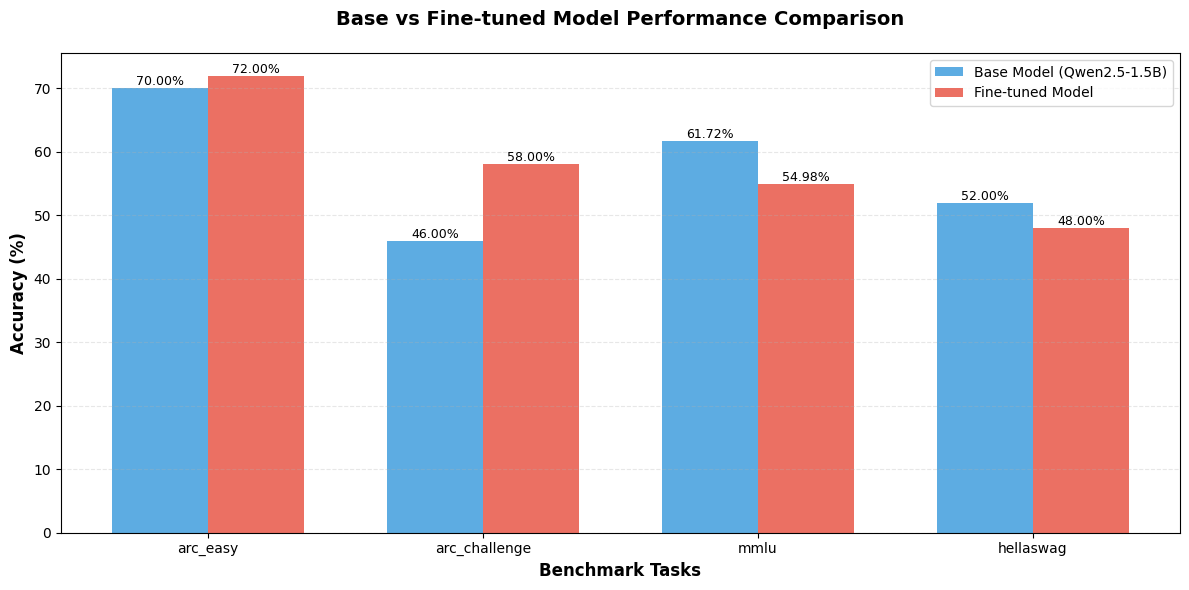

In [39]:
import matplotlib.pyplot as plt

# 막대 그래프 생성
fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(tasks))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], base_scores, width, 
               label='Base Model (Qwen2.5-1.5B)', alpha=0.8, color='#3498db')
bars2 = ax.bar([i + width/2 for i in x], finetuned_scores, width, 
               label='Fine-tuned Model', alpha=0.8, color='#e74c3c')

# 그래프 꾸미기
ax.set_xlabel('Benchmark Tasks', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('Base vs Fine-tuned Model Performance Comparison', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(tasks)
ax.legend(loc='upper right', fontsize=10)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# 값 표시
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}%',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


## 6. 고급 옵션


### Few-shot Learning 평가

Few-shot 예제의 개수를 지정하여 평가할 수 있습니다.


In [40]:
# 5-shot 평가
!lm_eval --model hf \
    --model_args pretrained=LGAI-EXAONE/EXAONE-3.5-2.4B-Instruct,trust_remote_code=True \
    --tasks mmlu \
    --num_fewshot 5 \
    --device cuda:0 \
    --batch_size 4 \
    --limit 20 \
    --output_path ./results/base_model_5shot


2025-12-29:02:14:50 WARNING  [__main__:369]  --limit SHOULD ONLY BE USED FOR TESTING.REAL METRICS SHOULD NOT BE COMPUTED USING LIMIT.
2025-12-29:02:14:50 INFO     [__main__:465] Selected Tasks: ['mmlu']
2025-12-29:02:14:50 WARNING  [evaluator:172] pretrained=pretrained=LGAI-EXAONE/EXAONE-3.5-2.4B-Instruct,trust_remote_code=True appears to be an instruct or chat variant but chat
        template is not applied. Recommend setting `apply_chat_template` (optionally `fewshot_as_multiturn`).
2025-12-29:02:14:50 INFO     [evaluator:202] Setting random seed to 0 | Setting numpy seed to 1234 | Setting torch manual seed to 1234 | Setting fewshot manual seed to 1234
2025-12-29:02:14:50 INFO     [evaluator:240] Initializing hf model, with arguments: {'pretrained': 'LGAI-EXAONE/EXAONE-3.5-2.4B-Instruct', 'trust_remote_code': True}
2025-12-29:02:14:50 INFO     [models.huggingface:158] Using device 'cuda:0'
2025-12-29:02:14:51 INFO     [models.huggingface:545] Model type cannot be determined. Using d

In [41]:
import json
import glob
from pprint import pprint

# The **/ search recursively through all subdirectories inside 'results'
search_pattern = './results/**/*.json'
files = glob.glob(search_pattern, recursive=True)

if not files:
    print("Still no JSON files found. Double check if the file extension is .json")
else:
    # Let's pick the one that contains 'base_model_5shot' in the name
    target_file = [f for f in files if 'base_model_5shot' in f.lower()]
    
    if target_file:
        file_path = target_file[0]
        print(f"Success! Found file: {file_path}")
        
        with open(file_path, 'r') as f:
            base_model_5shot = json.load(f)

        print("=== Base 모델 - base_model_5shot 결과 ===")
        pprint(base_model_5shot['results'])
    else:
        print("Found JSON files, but none with 'base_model_5shot' in the name:")
        print(files)

Success! Found file: ./results/base_model_5shot/LGAI-EXAONE__EXAONE-3.5-2.4B-Instruct/results_2025-12-29T02-20-51.963023.json
=== Base 모델 - base_model_5shot 결과 ===
{'mmlu': {'acc,none': 0.6070175438596491,
          'acc_stderr,none': 0.013843334601174548,
          'alias': 'mmlu'},
 'mmlu_abstract_algebra': {'acc,none': 0.25,
                           'acc_stderr,none': 0.09933992677987828,
                           'alias': '  - abstract_algebra'},
 'mmlu_anatomy': {'acc,none': 0.45,
                  'acc_stderr,none': 0.11413288653790232,
                  'alias': '  - anatomy'},
 'mmlu_astronomy': {'acc,none': 0.85,
                    'acc_stderr,none': 0.08191780219091253,
                    'alias': '  - astronomy'},
 'mmlu_business_ethics': {'acc,none': 0.65,
                          'acc_stderr,none': 0.1094243309804831,
                          'alias': '  - business_ethics'},
 'mmlu_clinical_knowledge': {'acc,none': 0.65,
                             'acc_stderr,none

### 로컬 모델 평가

로컬에 저장된 모델을 평가하는 방법입니다.


In [42]:
# 로컬 모델 평가 예시
# !lm_eval --model hf \
#     --model_args pretrained=/path/to/your/local/model,trust_remote_code=True \
#     --tasks hellaswag \
#     --device cuda:0 \
#     --batch_size 8 \
#     --output_path ./results/local_model

print("로컬 모델 평가를 위해 위 명령어의 주석을 제거하고 경로를 수정하세요.")


로컬 모델 평가를 위해 위 명령어의 주석을 제거하고 경로를 수정하세요.


### GGUF 모델 평가

GGUF 형식의 양자화된 모델을 평가할 수도 있습니다.


In [43]:
# GGUF 모델 평가 (llama.cpp 백엔드 사용)
# !lm_eval --model gguf \
#     --model_args filename=/path/to/model.gguf \
#     --tasks hellaswag \
#     --batch_size 8 \
#     --output_path ./results/gguf_model

print("GGUF 모델 평가를 위해 llama.cpp가 설치되어 있어야 합니다.")


GGUF 모델 평가를 위해 llama.cpp가 설치되어 있어야 합니다.


## 7. 주요 커맨드라인 옵션 정리

| 옵션 | 설명 | 예시 |
|------|------|------|
| `--model` | 모델 타입 지정 | `hf`, `gguf`, `openai` 등 |
| `--model_args` | 모델 매개변수 | `pretrained=model_name` |
| `--tasks` | 평가 태스크 지정 | `hellaswag,mmlu,arc_easy` |
| `--num_fewshot` | Few-shot 개수 | `0`, `5`, `10` 등 |
| `--device` | 실행 디바이스 | `cuda:0`, `cpu` |
| `--batch_size` | 배치 크기 | `8`, `16` 등 |
| `--limit` | 평가 샘플 수 제한 | `100` (전체는 None) |
| `--output_path` | 결과 저장 경로 | `./results/my_eval` |


## 8. Python API 사용하기

CLI 대신 Python API를 직접 사용할 수도 있습니다.


In [3]:
import tqdm

# 위젯 기반의 tqdm 대신 표준 텍스트 기반의 tqdm을 사용하도록 강제 설정
tqdm.tqdm = tqdm.std.tqdm

In [4]:
from lm_eval import simple_evaluate
from lm_eval.models.huggingface import HFLM

# Python API를 사용한 평가 예시
def evaluate_model_with_api(model_name, tasks, limit=None):
    # 모델 초기화
    model = HFLM(
        pretrained=model_name,
        device="cuda:0",
        batch_size=8,
        trust_remote_code=True
    )
    # 평가 실행
    results = simple_evaluate(
        model=model,
        tasks=tasks,
        num_fewshot=0,
        limit=limit
    )
    
    return results


In [5]:
# 사용 예시
results = evaluate_model_with_api(
    model_name="LGAI-EXAONE/EXAONE-3.5-2.4B-Instruct",
    tasks=["hellaswag"],
    limit=10
)


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.98G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/4.65G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

...

Generating test split:   0%|          | 0/10003 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10042 [00:00<?, ? examples/s]

Map:   0%|          | 0/39905 [00:00<?, ? examples/s]

Map:   0%|          | 0/10042 [00:00<?, ? examples/s]

Overwriting default num_fewshot of hellaswag from None to 0
Running loglikelihood requests:   0%|          | 0/40 [00:00<?, ?it/s]past_key_values should not be None in from_legacy_cache()
We detected that you are passing `past_key_values` as a tuple and this is deprecated and will be removed in v4.43. Please use an appropriate `Cache` class (https://huggingface.co/docs/transformers/v4.41.3/en/internal/generation_utils#transformers.Cache)
Running loglikelihood requests: 100%|██████████| 40/40 [00:01<00:00, 38.55it/s]
fatal: not a git repository (or any parent up to mount point /)
Stopping at filesystem boundary (GIT_DISCOVERY_ACROSS_FILESYSTEM not set).


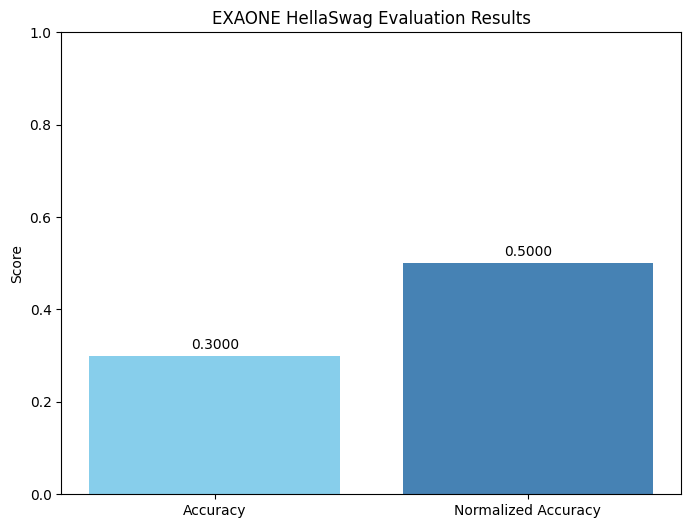

In [9]:
import matplotlib.pyplot as plt

# 1. Extract HellaSwag metrics from the 'results' object
# In v0.4.0+, metrics are stored with keys like 'acc,none' or 'acc_norm,none'
metrics = results['results']['hellaswag']
acc = metrics.get('acc,none', metrics.get('acc', 0))
acc_norm = metrics.get('acc_norm,none', metrics.get('acc_norm', 0))

labels = ['Accuracy', 'Normalized Accuracy']
values = [acc, acc_norm]

# 2. Generate the plot
fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(labels, values, color=['skyblue', 'steelblue'])

# 3. Add labels and style
ax.set_ylabel('Score')
ax.set_title('EXAONE HellaSwag Evaluation Results')
ax.set_ylim(0, 1.0)  # Most metrics are 0.0 to 1.0

# Add text labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.4f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom')

plt.show()

In [8]:
from pprint import pprint

pprint(results)


{'config': {'batch_size': None,
            'batch_sizes': [],
            'bootstrap_iters': 100000,
            'device': None,
            'fewshot_seed': 1234,
            'gen_kwargs': None,
            'limit': 10,
            'model': 'LGAI-EXAONE/EXAONE-3.5-2.4B-Instruct',
            'model_args': None,
            'model_dtype': torch.float32,
            'model_num_parameters': 2405327360,
            'model_revision': 'main',
            'model_sha': 'e949c91dec92095908d34e6b560af77dd0c993f8',
            'numpy_seed': 1234,
            'random_seed': 0,
            'torch_seed': 1234,
            'use_cache': None},
 'configs': {'hellaswag': {'dataset_path': 'Rowan/hellaswag',
                           'description': '',
                           'doc_to_choice': 'choices',
                           'doc_to_target': '{{label}}',
                           'doc_to_text': '{{query}}',
                           'fewshot_delimiter': '\n\n',
                           'meta

## 9. 요약 및 모범 사례

### 평가 모범 사례

1. **충분한 샘플 수**: 실제 성능 평가 시 `--limit` 옵션을 제거하거나 충분히 큰 값을 사용
2. **여러 태스크 평가**: 단일 벤치마크가 아닌 다양한 태스크에서 평가
3. **재현 가능성**: 같은 조건(seed, batch_size 등)으로 평가
4. **적절한 Few-shot 설정**: 태스크에 따라 적절한 few-shot 수 선택
5. **결과 저장**: `--output_path`로 결과를 저장하여 추후 비교


### Fine-tuning 효과 평가

Fine-tuning이 성공적이었는지 판단하는 기준:

- ✅ **향상**: 대부분의 태스크에서 정확도 증가
- ⚠️ **과적합**: 특정 태스크만 크게 향상, 다른 태스크는 성능 하락
- ❌ **퇴화**: 대부분의 태스크에서 성능 하락 (catastrophic forgetting)


## 10. 참고 자료

- **공식 문서**: https://github.com/EleutherAI/lm-evaluation-harness
- **지원 태스크 목록**: https://github.com/EleutherAI/lm-evaluation-harness/tree/main/lm_eval/tasks
- **Hugging Face Open LLM Leaderboard**: https://huggingface.co/spaces/HuggingFaceH4/open_llm_leaderboard
